<h1><center>Analyse de conversations patient-thérapeute sur la santé mentale</h1>

<p><center>La santé mentale est un enjeu majeur de la santé publique. Ce projet vise, dans un pre-
mier temps, à exploiter le jeu de données pour comprendre les types de conversations et leur
structure, puis à analyser les sentiments des échanges afin de détecter les émotions et états
psychologiques des patients. Ensuite, il se concentre sur l’accès et le traitement des conversa-
tions, en résumant les échanges et en identifiant les schémas linguistiques récurrents. Enfin, il
prévoit le développement d’un système question-réponse, capable d’automatiser les interactions
et fournir des réponses.</p>

<center><nav>
    <a href="https://www.kaggle.com/datasets/thedevastator/nlp-mental-health-conversations">Données</a> |
    <a href="https://github.com/cypnet/Analyse-de-conversations-sur-la-sant-mentale-/tree/Logan">Github</a>
</nav>

In [52]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [53]:
data_path = './train.csv'
df = pd.read_csv(data_path)
print(f"Détails nombre de lignes/colonnes: {df.shape}")
print(f"\nDétails des colonnes: {df.columns.tolist()}")
print(f"\nAperçu des premières lignes:")
df.head()

Détails nombre de lignes/colonnes: (3512, 2)

Détails des colonnes: ['Context', 'Response']

Aperçu des premières lignes:


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


<h3>Nettoyage des données (pré-traitement)</h3>

<h4>Cellules vides</h4> 

In [54]:
# On doit d'abord vérifier si il y a des cellules vides pour les deux colonnes
print("\nCellules vides (avant traitement): \n",df.isnull().sum())
df = df.dropna(subset=['Response', 'Context'])
print("\nCellules vides (après traitement): \n",df.isnull().sum())


Cellules vides (avant traitement): 
 Context     0
Response    4
dtype: int64

Cellules vides (après traitement): 
 Context     0
Response    0
dtype: int64


<h4>Doublons de cellules</h4>

In [55]:
# On vérifie ensuite si il y a des doublons de cellules
print("\nCellules dupliquées (avant traitement):",df.duplicated().sum())
df = df.drop_duplicates()
print("\nCellules dupliquées (après traitement):",df.duplicated().sum())


Cellules dupliquées (avant traitement): 760

Cellules dupliquées (après traitement): 0


In [56]:
# On vérifie que toute les cellules soient du type String et si ce n'est pas le cas (NaN) les remplacer par ''
df['Response'] = df['Response'].fillna('').astype(str)

# On regarde si les cellules Response et Context sont unique, si ce n'est pas le cas alors on supprimme les dupliquées
df = df.drop_duplicates(subset=['Response', 'Context'])

<h4>Passer tout les mots en minuscules</h4>
<p>Transformer tout les mots en minuscules nous permettra par la suite de les traiter plus facilement et éviter des situations telle que "toto" soit différent de "Toto".</p>

In [57]:
# compter les majuscules AVANT traitement
df['Response_upper'] = df['Response'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['Context_upper'] = df['Context'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\nNombre de majuscules dans Response (avant):", df['Response_upper'].sum())
print("Nombre de majuscules dans Context (avant):", df['Context_upper'].sum())

# transformer le texte en minuscules
df['Response'] = df['Response'].str.lower()
df['Context'] = df['Context'].str.lower()


# compter les majuscules APRES traitement
df['Response_upper_after'] = df['Response'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['Context_upper_after'] = df['Context'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\nNombre de majuscules dans Response (après):", df['Response_upper_after'].sum())
print("Nombre de majuscules dans Context (après):", df['Context_upper_after'].sum())


Nombre de majuscules dans Response (avant): 61125
Nombre de majuscules dans Context (avant): 20485

Nombre de majuscules dans Response (après): 0
Nombre de majuscules dans Context (après): 0


<h4>Suppression des espaces insécables (non-breaking space)</h4>
<p>Un espace insécable est définit par le caractère spéciale Unicode <code>'\xa0'</code>. Celui-ci peut se retrouver dans nos données puisque le fichier csv a été récupérée depuis le web, il ne faut donc pas oublier à le retirer.</p>

In [58]:
df['Response'] = df['Response'].str.replace(r'\s+', ' ', regex=True)
df['Context'] = df['Context'].str.replace(r'\s+', ' ', regex=True)

<h3>Quand est-il de la ponctuation ?</h3>
<p>Le faire trop tôt posera problème lors de la lemmatisation que l'on fera un peu plus bas</p>

<h4>Tokenisation</h4>
<p>On va maitenant "découper" les mots de chaque cellules en <i>tokens</i>.<br>
Pour pouvoir les définir, on va utiliser la librairie <b>spaCy</b> qui est une version un peut plus moderne que nltk (The Natural Language Toolkit) </p>

<p><i>Il faut au préalable télécharger le modèle pour pouvoir l'utiliser:</i> <code>python3 -m spacy download en_core_web_sm
</code></p>

In [59]:
import spacy
nlp = spacy.load("en_core_web_sm") # On charge spaCy dans python

<h5>Attention !</h5>
<p>Ici on traite une grande quantité de données, tokeniser (si ça se dit...) les mots bêtements va prendre énormément de temps, puisque spacy va devoir exécuter tokenize sur chaque ligne </p>
<p> On va devoir utiliser <code>nlp.pipe()</code> pour traiter les cellules en batch</p>

In [60]:
docs_response = list(nlp.pipe(df["Response"].astype(str), batch_size=200))
docs_context = list(nlp.pipe(df["Context"].astype(str), batch_size=200))

df['Response_tokens'] = [[token.text for token in doc] for doc in docs_response]
df['Context_tokens'] = [[token.text for token in doc] for doc in docs_context]

In [61]:
# On affiche le nombre de token total
nb_tokens_response = df['Response_tokens'].apply(len).sum()
nb_tokens_context = df['Context_tokens'].apply(len).sum()
print(f"Nombre total de tokens: {nb_tokens_response + nb_tokens_context}")
print(f"\nNombre total de tokens dans Response: {nb_tokens_response}")
print(f"Nombre total de tokens dans Context: {nb_tokens_context}")

# On affiche les 5 tokens les plus fréquents dans Response et Context pour avoir un apperçu
resp_tokens = [token for tokens in df['Response_tokens'] for token in tokens]
cont_tokens = [token for tokens in df['Context_tokens'] for token in tokens]
print(f"\n5 tokens les plus fréquents dans Response: {Counter(resp_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Context: {Counter(cont_tokens).most_common(5)}")

Nombre total de tokens: 734153

Nombre total de tokens dans Response: 553023
Nombre total de tokens dans Context: 181130

5 tokens les plus fréquents dans Response: [('you', 22141), ('to', 20197), ('.', 19983), (',', 19421), ('the', 13262)]
5 tokens les plus fréquents dans Context: [('i', 12876), ('.', 10452), ('and', 5396), ('to', 5185), (',', 5044)]


<p><i>On remarque que la plupart des mots les plus utilisés ne sont que des mots dit "vide"...</i></p>

<h3>Ponctuations</h3>
<p>Cela nous permettra de trier les mots plus facilement plus tard.</p>

In [62]:
# Nombre de token "ponctuations" avant traitement
def count_ponctuation(tokens):
    return sum(1 for token in tokens if getattr(token, "is_punct", False))

nb_ponctuations_response = sum(count_ponctuation(doc) for doc in docs_response)
nb_ponctuations_context = sum(count_ponctuation(doc) for doc in docs_context)

print(f"\nNombre de tokens de ponctuation dans Response (avant traitement): {nb_ponctuations_response}")
print(f"Nombre de tokens de ponctuation dans Context (avant traitement): {nb_ponctuations_context}")

df["Response_tokens_no_punct"] = [
    [token.text for token in doc if not token.is_punct]
    for doc in docs_response
]

df["Context_tokens_no_punct"] = [
    [token.text for token in doc if not token.is_punct]
    for doc in docs_context
]

# Après suppression, avec la même logique, il ne devrait plus rester de tokens ponctuation
nb_ponctuations_response_no_punct = sum(
    count_ponctuation([token for token in doc if not token.is_punct]) for doc in docs_response
)
nb_ponctuations_context_no_punct = sum(
    count_ponctuation([token for token in doc if not token.is_punct]) for doc in docs_context
)

# Nombre de token de ponctuation après suppression
print(f"Nombre de tokens de ponctuation dans Response (après traitement): {nb_ponctuations_response_no_punct}")
print(f"Nombre de tokens de ponctuation dans Context (après traitement): {nb_ponctuations_context_no_punct}")


Nombre de tokens de ponctuation dans Response (avant traitement): 53128
Nombre de tokens de ponctuation dans Context (avant traitement): 18704
Nombre de tokens de ponctuation dans Response (après traitement): 0
Nombre de tokens de ponctuation dans Context (après traitement): 0


<h4>Suppression des StopWords</h4>
<p>Des <i>stopwords</i> (ou mots vides en français) sont des mots n'ayant pas de réelle significations. Ses mots sont souvents des adverbes, des pronoms ou encore des mots de liaisons.<br> 
<i>source: <a href="https://fr.wikipedia.org/wiki/Mot_vide">Wikipedia: Mot Vide</a> </i> </p>

In [63]:
df["Response_tokens_no_stop"] = [
    [token.text for token in doc if not token.is_stop]
    for doc in docs_response
]

df["Context_tokens_no_stop"] = [
    [token.text for token in doc if not token.is_stop]
    for doc in docs_context
]

# On compare les résultats de tokens avec tokens_no_stop
print(f"\n5 tokens les plus fréquents dans Response (avec stopwords): {Counter(resp_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Response (sans stopwords): {Counter([token for tokens in df['Response_tokens_no_stop'] for token in tokens]).most_common(5)}")
print(f"\n5 tokens les plus fréquents dans Context (avec stopwords): {Counter(cont_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Context (sans stopwords): {Counter([token for tokens in df['Context_tokens_no_stop'] for token in tokens]).most_common(5)}")


5 tokens les plus fréquents dans Response (avec stopwords): [('you', 22141), ('to', 20197), ('.', 19983), (',', 19421), ('the', 13262)]
5 tokens les plus fréquents dans Response (sans stopwords): [('.', 19983), (',', 19421), ('"', 2780), ('feel', 2121), ('help', 1863)]

5 tokens les plus fréquents dans Context (avec stopwords): [('i', 12876), ('.', 10452), ('and', 5396), ('to', 5185), (',', 5044)]
5 tokens les plus fréquents dans Context (sans stopwords): [('.', 10452), (',', 5044), ('?', 1844), ('feel', 991), ('like', 919)]


<h4>Lemmatisation</h4>
<p>Et enfin, il nous faut transformer les mots (tokens) en leurs forme de base, par exemple "running" deviendra "run", ou bien "better" deviendra "good". <br>
Cela permettra d'une part de diminuer drastiquement le nombre de tokens mais aussi de regrouper des mots qui sont similaires</p>

In [64]:
df["Response_clean"] = [
    [
        token.lemma_
        for token in doc
        if not token.is_stop    # stopwords
        and not token.is_punct  # ponctuation
        and not token.is_space  # espaces
    ]
    for doc in docs_response
]

df["Context_clean"] = [
    [
        token.lemma_
        for token in doc
        if not token.is_stop    # stopwords
        and not token.is_punct  # ponctuation
        and not token.is_space  # espaces
    ]
    for doc in docs_context
]

In [65]:
# On affiche maintenant le nombre de tokens après lemmatisation
nb_tokens_response_clean = df['Response_clean'].apply(len).sum()
nb_tokens_context_clean = df['Context_clean'].apply(len).sum()
print(f"Nombre total de tokens après lemmatisation: {nb_tokens_response_clean + nb_tokens_context_clean}")
print(f"\nNombre total de tokens dans Response après lemmatisation: {nb_tokens_response_clean}")
print(f"Nombre total de tokens dans Context après lemmatisation: {nb_tokens_context_clean}")

Nombre total de tokens après lemmatisation: 254224

Nombre total de tokens dans Response après lemmatisation: 200180
Nombre total de tokens dans Context après lemmatisation: 54044


In [66]:
# Apperçus du DataFrame après le traitement
df.head()

,Context,Response,Response_upper,Context_upper,Response_upper_after,Context_upper_after,Response_tokens,Context_tokens,Response_tokens_no_punct,Context_tokens_no_punct,Response_tokens_no_stop,Context_tokens_no_stop,Response_clean,Context_clean
0,i'm going through some things with my feelings...,"if everyone thinks you're worthless, then mayb...",10,10,0,0,"[if, everyone, thinks, you, 're, worthless, ,,...","[i, 'm, going, through, some, things, with, my...","[if, everyone, thinks, you, 're, worthless, th...","[i, 'm, going, through, some, things, with, my...","[thinks, worthless, ,, maybe, need, find, new,...","[going, things, feelings, ., barely, sleep, th...","[think, worthless, maybe, need, find, new, peo...","[go, thing, feeling, barely, sleep, think, wor..."
1,i'm going through some things with my feelings...,"hello, and thank you for your question and see...",43,10,0,0,"[hello, ,, and, thank, you, for, your, questio...","[i, 'm, going, through, some, things, with, my...","[hello, and, thank, you, for, your, question, ...","[i, 'm, going, through, some, things, with, my...","[hello, ,, thank, question, seeking, advice, ....","[going, things, feelings, ., barely, sleep, th...","[hello, thank, question, seek, advice, feeling...","[go, thing, feeling, barely, sleep, think, wor..."
2,i'm going through some things with my feelings...,first thing i'd suggest is getting the sleep y...,5,10,0,0,"[first, thing, i, 'd, suggest, is, getting, th...","[i, 'm, going, through, some, things, with, my...","[first, thing, i, 'd, suggest, is, getting, th...","[i, 'm, going, through, some, things, with, my...","[thing, suggest, getting, sleep, need, impact,...","[going, things, feelings, ., barely, sleep, th...","[thing, suggest, get, sleep, need, impact, thi...","[go, thing, feeling, barely, sleep, think, wor..."
3,i'm going through some things with my feelings...,therapy is essential for those that are feelin...,14,10,0,0,"[therapy, is, essential, for, those, that, are...","[i, 'm, going, through, some, things, with, my...","[therapy, is, essential, for, those, that, are...","[i, 'm, going, through, some, things, with, my...","[therapy, essential, feeling, depressed, worth...","[going, things, feelings, ., barely, sleep, th...","[therapy, essential, feel, depressed, worthles...","[go, thing, feeling, barely, sleep, think, wor..."
4,i'm going through some things with my feelings...,i first want to let you know that you are not ...,3,10,0,0,"[i, first, want, to, let, you, know, that, you...","[i, 'm, going, through, some, things, with, my...","[i, first, want, to, let, you, know, that, you...","[i, 'm, going, through, some, things, with, my...","[want, let, know, feelings, help, ., change, f...","[going, things, feelings, ., barely, sleep, th...","[want, let, know, feeling, help, change, feeli...","[go, thing, feeling, barely, sleep, think, wor..."


<p><i>On précise bien entendu que toute les étapes peuvent se résumer dans la lemmatisation, le but ici est de détailler toutes les étapes de traitement</i></p>

<h3>Analyse Statistique</h3>

<h4>Nombre de patients uniques</h4>

<p>Il n'y a pas vraiment de façon directe (ou du moins assez fiable) pour définir un patient d'un autre sans un identifiant, la seul façon ici serait de définir une cellule pour un patient et une cellule pour un thérapeute (<b>sans compter les doublons</b>). <br>
Une des suppositions que l'on peut faire serait que chaque cellules patients dupliquée serait un unique patient, celui-ci évoquant la même discussion avec différents thérapeutes. <br>
Cette solution peut fonctionner est très approximative, surtout pour les thérapeutes.</p>

In [67]:
# On compte le nombre de patients uniques dans context_clean
unique_patients = df['Context'].nunique()
print(f"\nNombre de patients uniques: {unique_patients}")


Nombre de patients uniques: 831


<h4>Nombre de thérapeutes uniques</h4>

In [68]:
# On compte le nombre de thérapeutes uniques
unique_therapeutes = df['Response'].nunique()
print(f"Nombre de thérapeutes uniques: {unique_therapeutes}")

Nombre de thérapeutes uniques: 2452


<h4>Distribution des conversations par thérapeute</h4>
<p>On cherche ici combien de conversations peut avoir un thérapeute avec un ou plusieurs patients. Or le problème ici est que, comme au dessus, on a pas d'ID pour les thérapeutes ni pour les patients, donc aucuns moyens de déterminer le nombre de conversations par thérapeutes. </p>

In [69]:
distribution = df['Response'].value_counts()
print(f"\nDistribution des thérapeutes:\n{distribution}")


Distribution des thérapeutes:
Response
i'm sorry to hear that you are unable to get through to your parents. it sounds like you are experiencing a great deal of anxiety that needs to be addressed by a professional (despite the fact that you are unable to at the moment). i would recommend talking with another adult such as a school counselor that can offer you support in this area. perhaps they can work with you on your anxiety issues and schedule a meeting with your parents so that he/she may help mediate the conversation with them.if you are unable to reach out to a school counselor maybe you can try a member of the family such as an aunt or an uncle that feels comfortable addressing the issue with your parents. sometimes it helps hearing it from a third party before the situations is taken seriously enough.good luck!                                                                                                                                                                         

<h4>Nombre d'échanges moyen par conversation</h4>
<p>Ici, on cherche à voir le nombre de mots moyens par patients/thérapeutes</p>

In [70]:
# Nombre de mots moyens par patients
mean_context_w_stopwords = df['Context'].apply(len).mean()
mean_context_wo_stopwords = df['Context_tokens_no_stop'].apply(len).mean()
mean_context_w_lemmas = df['Context_clean'].apply(len).mean()
print(f"\nNombre de mots moyens par patients (avec stopwords): {mean_context_w_stopwords:.2f}")
print(f"Nombre de mots moyens par patients (sans stopwords): {mean_context_wo_stopwords:.2f}")
print(f"Nombre de mots moyens par patients (avec lemmatisation): {mean_context_w_lemmas:.2f}")

print("\n")

# Nombre de mots moyens par thérapeutes
mean_response_w_stopwords = df['Response'].apply(len).mean()
mean_response_wo_stopwords = df['Response_tokens_no_stop'].apply(len).mean()
mean_response_w_lemmas = df['Response_clean'].apply(len).mean()
print(f"Nombre de mots moyens par thérapeutes (avec stopwords): {mean_response_w_stopwords:.2f}")
print(f"Nombre de mots moyens par thérapeutes (sans stopwords): {mean_response_wo_stopwords:.2f}")
print(f"Nombre de mots moyens par thérapeutes (avec lemmatisation): {mean_response_w_lemmas:.2f}")


Nombre de mots moyens par patients (avec stopwords): 289.70
Nombre de mots moyens par patients (sans stopwords): 26.47
Nombre de mots moyens par patients (avec lemmatisation): 19.67


Nombre de mots moyens par thérapeutes (avec stopwords): 1033.97
Nombre de mots moyens par thérapeutes (sans stopwords): 92.19
Nombre de mots moyens par thérapeutes (avec lemmatisation): 72.85


<h4>Mots les plus utilisés</h4>

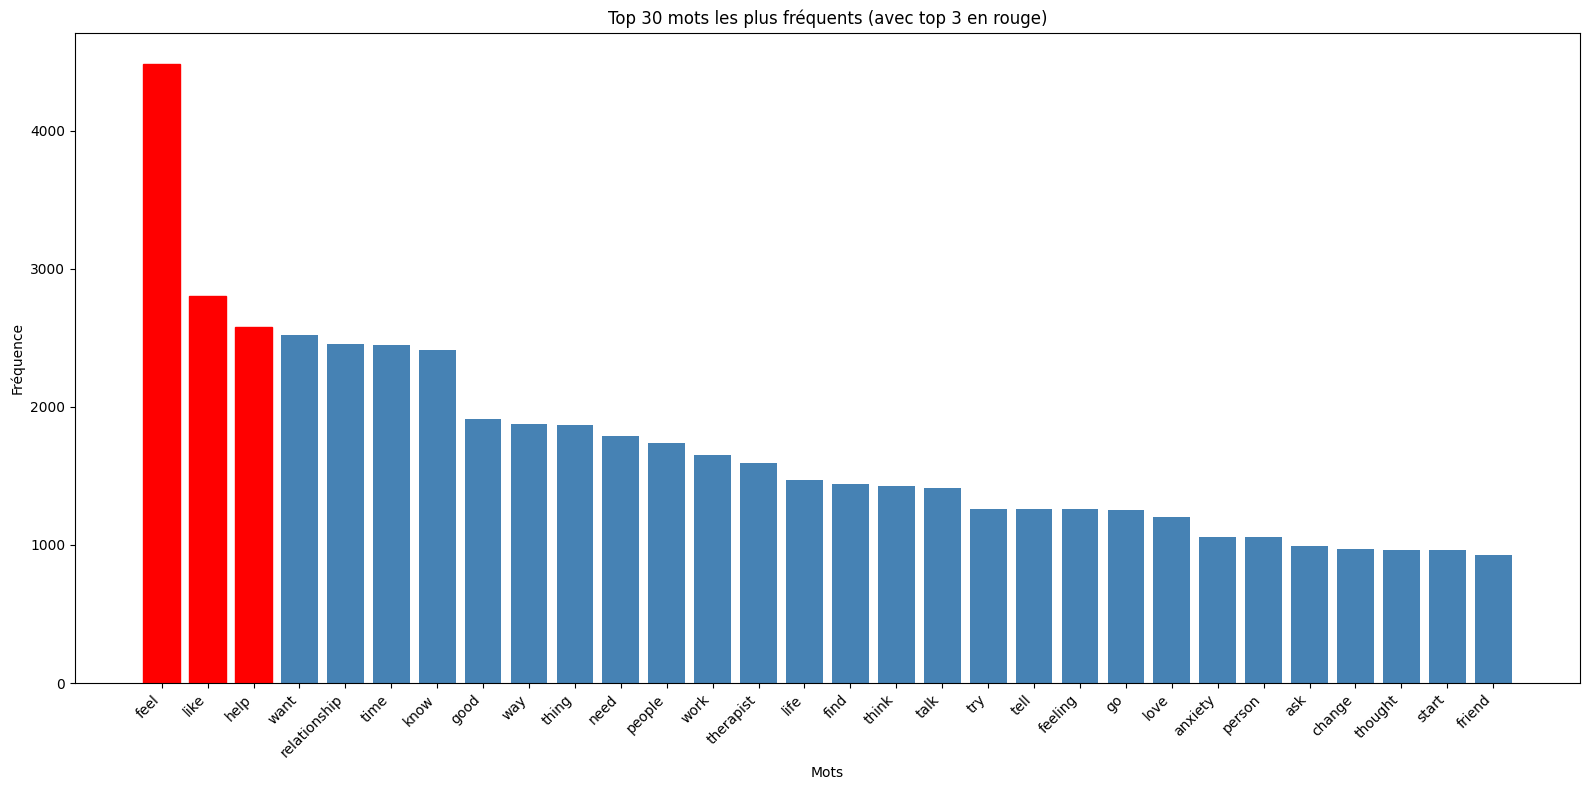

Trois mots les plus utilisés (avec leurs fréquences) :
- feel: 4485 fois
- like: 2802 fois
- help: 2580 fois


In [71]:
# On créer un graphique avec la liste de tout les mots et leurs nombre d'apparition sur tout le corpus
all_tokens = [token for tokens in df['Context_clean'] for token in tokens] + [token for tokens in df['Response_clean'] for token in tokens]

# Nettoyage des tokens courts (contractions résiduelles comme "m" / "s" après suppression de ponctuation)
all_tokens = [token for token in all_tokens if len(token) > 1]

# Re-compter les tokens
all_token_counts = Counter(all_tokens)

# Top 3 mots les plus fréquents (mis en évidence en rouge)
top3 = all_token_counts.most_common(3)
top3_tokens = [token for token, _ in top3]

# Préparer les données pour affichage (top 30 pour lisibilité)
top_n = 30
most_common = all_token_counts.most_common(top_n)
words = [token for token, _ in most_common]
counts = [count for _, count in most_common]

plt.figure(figsize=(16, 8))
bars = plt.bar(words, counts, color=['red' if w in top3_tokens else 'steelblue' for w in words])

for i, (word, count) in enumerate(most_common):
    if word in top3_tokens:
        bars[i].set_color('red')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 mots les plus fréquents (avec top 3 en rouge)')
plt.tight_layout()
plt.show()

# Afficher les 3 mots les plus utilisés en gros
print('Trois mots les plus utilisés (avec leurs fréquences) :')
for token, freq in top3:
    print(f'- {token}: {freq} fois')

<p>On remarque ici que <i>feel</i> et <i>feeling</i> sont deux termes distincts, alors qu'après la lemmatisation ils auraient du se fusionner en un seul terme <i>feel</i>. Cela viens du fait que spaCy lemmatise différemment selon le <b>contexte grammatical</b> du mot. <br>
Quand feeling est utilisé comme nom (<i>"a feeling of anxiety"</i>), spaCy le garde tel quel au lieu de le ramener à <i>feel</i>.</p>

<h3>Analyse Lexicale</h3>

In [72]:
# TODO

<h3>Modélisation et extraction de sujets (Topic Modeling)</h3>

In [73]:
# TODO